# Imports

In [1]:
import numpy as np
import types as tp
import time
import matplotlib.pyplot as plt
from scipy import stats

from Snakes_and_Ladders import SnakesAndLadders as SL

# Game Creation

The game used for analysis is the following:
![Image](https://upload.wikimedia.org/wikipedia/commons/b/b0/Snakes_and_Ladders_board.jpg)

The image was found here: [https://commons.wikimedia.org/wiki/File:Snakes_and_Ladders_board.jpg](https://commons.wikimedia.org/wiki/File:Snakes_and_Ladders_board.jpg)

In [2]:
# Shared variables
numsqrs = 100
snks = [[29,7],[38,20],[44,14],[55,11],[62,40],[73,52],[82,60],[93,43],[96,17],[98,48]]
lddrs = [[3,21],[4,36],[15,48],[24,58],[31,70],[49,90],[60,79],[63,99],[72,91],[77,97]]


# Classic game, where overflows (rolled squares greater than the last on the board) count as the last square
slg_c = SL(numSquares=numsqrs, Snakes=snks, Ladders=lddrs, Overflow='classic')

# Rollback game, where overflows are subtracted from the last square
slg_r = SL(numSquares=numsqrs, Snakes=snks, Ladders=lddrs, Overflow='rollback')

# Ignore game, where overflows aren't counted and the turn is effectively skipped
slg_i = SL(numSquares=numsqrs, Snakes=snks, Ladders=lddrs, Overflow='ignore')


# Analyse Results
## 1. Square Frequency
### 1.1. Play Games (with separate snake/ladder turns)

In [3]:
# Shared variables
numplyrs = 1
numtms = 10000
mxtrns = 100
Vrbsty = 'none'
spTrns = True

# Stores list logging each player's squares for each turn of each game, as well as display the time to run them (~4-8s each with similar computer 
# performance and settings (numplyrs = 1, numtms = 10000, mxtrns = 100))
startTime = time.time() # Time before games are ran

# Classic game (overflows (rolled squares greater than the last) count as last square)
gl_c = slg_c.play_game(numPlayers=numplyrs, numTimes=numtms, maxTurns=mxtrns, Verbosity=Vrbsty, sepSLturns=spTrns)
totalTime_gl_c = time.time() # Time after classic game
time_gl_c = totalTime_gl_c - startTime # Classic game running time
print(f"Classic game running time: {time_gl_c} s")

# Rollover game (overflows are subtracted from last square)
gl_r = slg_r.play_game(numPlayers=numplyrs, numTimes=numtms, maxTurns=mxtrns, Verbosity=Vrbsty, sepSLturns=spTrns)
totalTime_gl_r = time.time() # Time after classic and rollover games
time_gl_r = totalTime_gl_r - totalTime_gl_c # Rollover game running time
print(f"Rollover game running time: {time_gl_r} s")

# Ignore game (overflows aren't counted, so the turn is skipped)
gl_i = slg_i.play_game(numPlayers=numplyrs, numTimes=numtms, maxTurns=mxtrns, Verbosity=Vrbsty, sepSLturns=spTrns)
totalTime_gl_i = time.time() # Time after classic, rollover and ignore games
time_gl_i = totalTime_gl_i - totalTime_gl_r # Ignore game running time
print(f"Ignore game running time: {time_gl_i} s")

Classic game running time: 4.158226013183594 s
Rollover game running time: 6.789238929748535 s
Ignore game running time: 5.091474533081055 s


### 1.2. Square frequency generation

In [4]:
def get_square_frequency(gamesList, numSquares):
    ''' Gets the frequency of each square in a games list.

        Inputs:
     gamesList: The list with the arrays containing the square numbers each player were on in each turn in a game, starting from the zeroth turn at
     square 1. For each game array, the rows are the players and the columns are the turns.
     numSquares: The number of squares on the board.

        Outputs:
     squareFreq: The dictionary where the keys are the square numbers and the values are the frequency.
    '''

    ## Predefines flattened game list for later loop
    flatGamesList = None

    ## Flattened game list loop
    for game in gamesList:
        ### Flattens games into 1D shape
        flatGame = np.ravel(game)

        ### Adds flattened game to (flattened) game list
        if type(flatGamesList) == tp.NoneType: ### Checks if flatGamesList has no value assigned to it
            flatGamesList = flatGame
        else:
            flatGamesList = np.concat((flatGamesList, flatGame))

    
    ## Predefines the square frequency dictionary to allow for selective updating and possibly faster speeds
    squareFreqKeys = range(1, numSquares + 1) ## Keys, i.e. square numbers
    squareFreqValues = np.zeros_like(squareFreqKeys) ## Values, i.e. frequency of the squares (set to 0 as default value)
    squareFreq = dict(zip(squareFreqKeys, squareFreqValues)) ## zip creates tuple pairs, e.g. (1,0), (2,0) etc.

    ## Gets unique square numbers in (flattened) game list for later loop
    uniqueGamesList = np.unique(flatGamesList)
    
    ## Square frequency dictionary loop
    for num in uniqueGamesList:
        ### Gets values in (flat)GamesList that match current square number
        numGamesList = flatGamesList[flatGamesList == num]

        ### Finds square frequency value from length of previous list
        squareFreqNum = len(numGamesList)

        ### Adds value to dictionary
        squareFreq[num] = squareFreqNum

    ## Returns square frequency dictionary
    return squareFreq


# Test for get_square_frequency
gl_test = [np.array([[1,2,3],[4,5,6]]), np.array([[7,8,9,10],[1,2,3,4]])]
#print(gl_test)
squareFreq_test = get_square_frequency(gamesList=gl_test, numSquares=10)
#print(squareFreq_test)


# Find square frequencies of played games, as well as shows the time taken to calculate them (~6-12s each with similar computer performance and 
# settings (numplyrs = 1, numtms = 10000, mxtrns = 100))
startTime_squareFreq = time.time() # Time before games are ran

# Classic game square frequency 
squareFreq_c = get_square_frequency(gamesList=gl_c, numSquares=numsqrs)
totalTime_squareFreq_c = time.time() # Time after classic game square frequency calculation
time_squareFreq_c = totalTime_squareFreq_c - startTime_squareFreq # Classic game square frequency calculation running time
print(f"Classic game square freq. calc. running time: {time_squareFreq_c} s")

# Rollover game square frequency 
squareFreq_r = get_square_frequency(gamesList=gl_r, numSquares=numsqrs)
totalTime_squareFreq_r = time.time() # Time after classic and rollover games' square frequency calculation
time_squareFreq_r = totalTime_squareFreq_r - totalTime_squareFreq_c # Rollover game square frequency calculation running time
print(f"Rollover game square freq. calc. running time: {time_squareFreq_r} s")

# Ignore game square frequency 
squareFreq_i = get_square_frequency(gamesList=gl_i, numSquares=numsqrs)
totalTime_squareFreq_i = time.time() # Time after classic, rollover and ignore games' square frequency calculation
time_squareFreq_i = totalTime_squareFreq_i - totalTime_squareFreq_r # Ignore game square frequency calculation running time
print(f"Ignore game square freq. calc. running time: {time_squareFreq_i} s")

Classic game square freq. calc. running time: 6.6032631397247314 s
Rollover game square freq. calc. running time: 11.242863893508911 s
Ignore game square freq. calc. running time: 7.531778573989868 s


### 1.3. Relative frequency plots

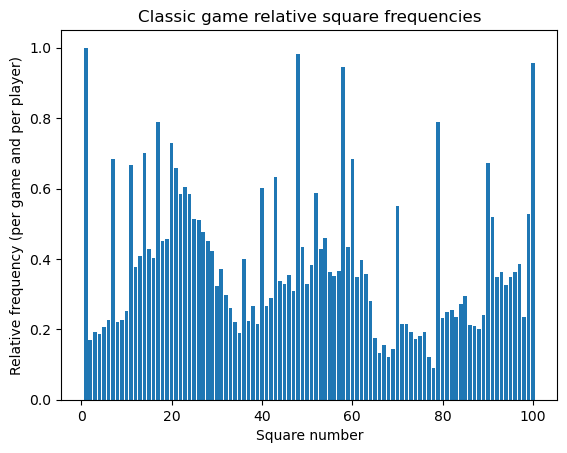

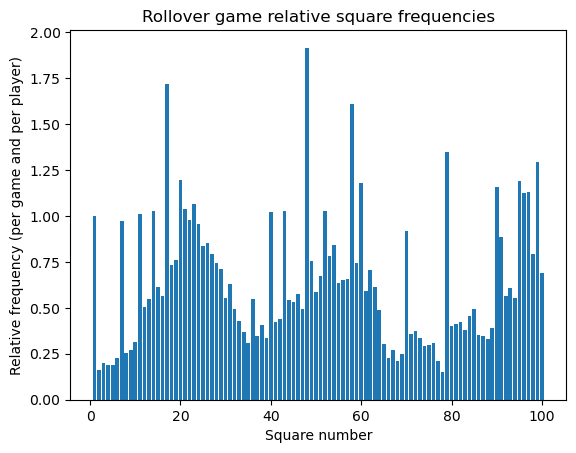

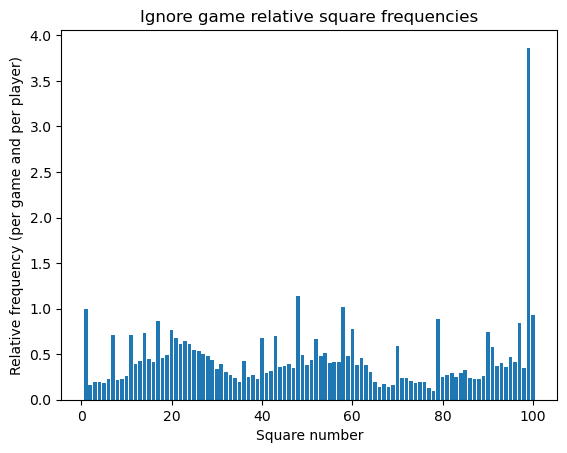

In [5]:
# Gets square numbers and square frequency numbers in separate variables for later graphs
squareNums = list(squareFreq_c.keys()) # Converted from dictionary view to list

squareFreqNums_c = list(squareFreq_c.values())
squareFreqNums_r = list(squareFreq_r.values())
squareFreqNums_i = list(squareFreq_i.values())


# Calculates relative square frequency (per player and per game)
relSquareFreqNums_c = np.array(squareFreqNums_c)/(numtms*numplyrs) # Converted into a NumPy array to allow for division
relSquareFreqNums_r = np.array(squareFreqNums_r)/(numtms*numplyrs)
relSquareFreqNums_i = np.array(squareFreqNums_i)/(numtms*numplyrs)


# Plots relative square frequencies as bar graphs

# Shared variables
xLbl = 'Square number'
yLbl = 'Relative frequency (per game and per player)'

# Classic game bar graph
fig, ax = plt.subplots()
ax.bar(squareNums, relSquareFreqNums_c)
ax.set_xlabel(xLbl)
ax.set_ylabel(yLbl)
ax.set_title('Classic game relative square frequencies')
plt.show()

# Rollover game bar graph
fig, ax = plt.subplots()
ax.bar(squareNums, relSquareFreqNums_r)
ax.set_xlabel(xLbl)
ax.set_ylabel(yLbl)
ax.set_title('Rollover game relative square frequencies')
plt.show()

# Ignore game bar graph
fig, ax = plt.subplots()
ax.bar(squareNums, relSquareFreqNums_i)
ax.set_xlabel(xLbl)
ax.set_ylabel(yLbl)
ax.set_title('Ignore game relative square frequencies')
plt.show()


## 2. Game length
### 2.1. Play Games (without separate snake/ladder turns)

In [6]:
# Shared variables
numplyrs = 1
numtms = 100000
mxtrns = 1000
Vrbsty = 'none'
spTrns = False

# Stores list logging each player's squares for each turn of each game, as well as display the time to run them (~40-90s each with similar computer 
# performance and settings (numplyrs = 1, numtms = 100000, mxtrns = 1000))
startTime2 = time.time() # Time before games are ran

# Classic game (overflows (rolled squares greater than the last) count as last square)
gl_c2 = slg_c.play_game(numPlayers=numplyrs, numTimes=numtms, maxTurns=mxtrns, Verbosity=Vrbsty, sepSLturns=spTrns)
totalTime_gl_c2 = time.time() # Time after classic game
time_gl_c2 = totalTime_gl_c2 - startTime2 # Classic game running time
print(f"Classic game running time: {time_gl_c2} s")

# Rollover game (overflows are subtracted from last square)
gl_r2 = slg_r.play_game(numPlayers=numplyrs, numTimes=numtms, maxTurns=mxtrns, Verbosity=Vrbsty, sepSLturns=spTrns)
totalTime_gl_r2 = time.time() # Time after classic and rollover games
time_gl_r2 = totalTime_gl_r2 - totalTime_gl_c2 # Rollover game running time
print(f"Rollover game running time: {time_gl_r2} s")

# Ignore game (overflows aren't counted, so the turn is skipped)
gl_i2 = slg_i.play_game(numPlayers=numplyrs, numTimes=numtms, maxTurns=mxtrns, Verbosity=Vrbsty, sepSLturns=spTrns)
totalTime_gl_i2 = time.time() # Time after classic, rollover and ignore games
time_gl_i2 = totalTime_gl_i2 - totalTime_gl_r2 # Ignore game running time
print(f"Ignore game running time: {time_gl_i2} s")

Classic game running time: 39.646103382110596 s
Rollover game running time: 87.51518082618713 s
Ignore game running time: 48.22066688537598 s


### 2.2 Game length calculation

In [7]:
def get_game_lengths(gamesList):
    ''' Gets the number of turns each game lasts in a games list.
    
        Inputs:
    gamesList: The list with the arrays containing the square numbers each player were on in each turn in a game, starting from the zeroth turn at
    square 1. For each game array, the rows are the players and the columns are the turns.
    
        Outputs:
    gameLengths: A list of game lengths, ordered by the games in the original game length.
    '''

    ## Predefines game lengths list for later loop
    gameLengths = []
    
    ## Game lengths list loop
    for game in gamesList:
        ### gets length (number of turns) in the game
        gameShape = np.shape(game)
        length = gameShape[1] - 1 # Subtracted by one to account for 'zeroth' turn at square 1
    
        ### Adds game length to game lengths list
        gameLengths.append(length)

    return gameLengths


# Test for get_square_frequency
gl_test2 = [np.array([[1,2,3],[4,5,6]]), np.array([[7,8,9,10],[1,2,3,4]]), np.array([[5],[6]])]
#print(gl_test2)
squareFreq_test2 = get_game_lengths(gamesList=gl_test2)
#print(squareFreq_test2)


# Find square frequencies of played games, as well as shows the time taken to calculate them (negligible time with similar computer performance and 
# settings (numplyrs = 1, numtms = 100000, mxtrns = 1000))
startTime_gameLengths = time.time() # Time before games are ran

# Classic game lengths 
gameLengths_c = get_game_lengths(gamesList=gl_c2) 
totalTime_gameLengths_c = time.time() # Time after classic game lengths calculation
time_gameLengths_c = totalTime_gameLengths_c - startTime_gameLengths # Classic game lengths calculation running time
print(f"Classic game lengths calc. running time: {time_gameLengths_c} s")

# Rollover game lengths 
gameLengths_r = get_game_lengths(gamesList=gl_r2)
totalTime_gameLengths_r = time.time() # Time after classic and rollover games' lengths calculation
time_gameLengths_r = totalTime_gameLengths_r - totalTime_gameLengths_c # Rollover game lengths calculation running time
print(f"Rollover game lengths calc. running time: {time_gameLengths_r} s")

# Ignore game lengths 
gameLengths_i = get_game_lengths(gamesList=gl_i2)
totalTime_gameLengths_i = time.time() # Time after classic, rollover and ignore games' lengths calculation
time_gameLengths_i = totalTime_gameLengths_i - totalTime_gameLengths_i # Ignore game lengths calculation running time
print(f"Ignore game lengths calc. running time: {time_gameLengths_i} s")

Classic game lengths calc. running time: 0.09456825256347656 s
Rollover game lengths calc. running time: 0.09177255630493164 s
Ignore game lengths calc. running time: 0.0 s


### 2.3. Game Length plots

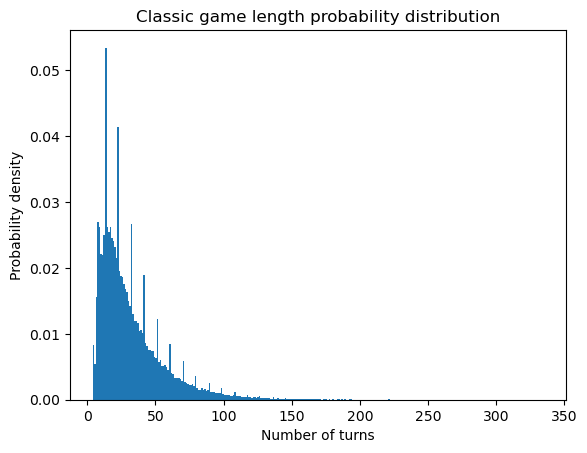

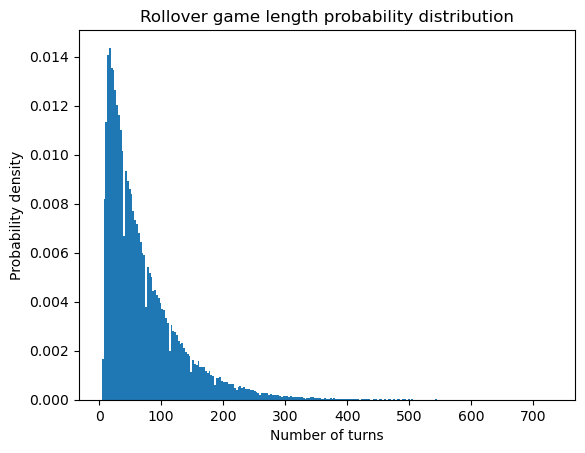

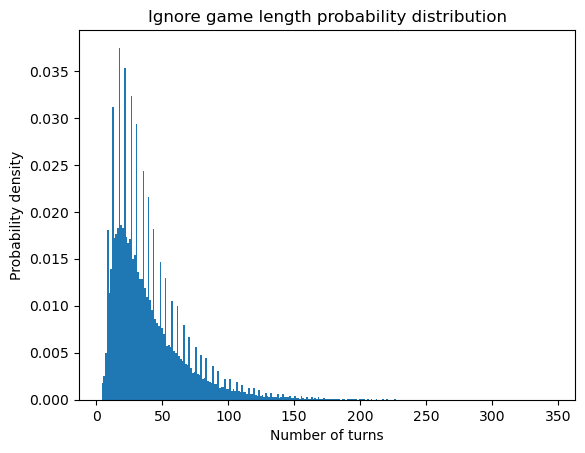

In [8]:
# Shared variable
bn = 'auto'
dnsty = True # Whether the histograms show probability densities
xLbl = 'Number of turns'
gameName = ['Classic', 'Rollover', 'Ignore']

if dnsty == True:
    yLbl = 'Probability density'
    title = ' game length probability distribution'
else:
    yLbl = 'Count'
    title = ' game length histogram'

# Classic game histogram
fig, ax = plt.subplots()
ax.hist(gameLengths_c, bins=bn, density=dnsty)
ax.set_xlabel(xLbl)
ax.set_ylabel(yLbl)
ax.set_title(gameName[0]+title)
plt.show()

# Rollover game histogram
fig, ax = plt.subplots()
ax.hist(gameLengths_r, bins=bn, density=dnsty)
ax.set_xlabel(xLbl)
ax.set_ylabel(yLbl)
ax.set_title(gameName[1]+title)
plt.show()

# Ignore game histogram
fig, ax = plt.subplots()
ax.hist(gameLengths_i, bins=bn, density=dnsty)
ax.set_xlabel(xLbl)
ax.set_ylabel(yLbl)
ax.set_title(gameName[2]+title)
plt.show()

### 2.4. Game Length Summary Statistics

In [9]:
# Classic game
median_gameLength_c = np.median(gameLengths_c)
mode_gameLengths_c = stats.mode(gameLengths_c)

print("\t Classic game summary statistics")
print(stats.describe(gameLengths_c)) # Shows several summary statistics, with nobs being the number of observations
print(f"Median: {median_gameLength_c}")
print(f"Mode: {mode_gameLengths_c}")


# Rollover game
median_gameLength_r = np.median(gameLengths_r)
mode_gameLengths_r = stats.mode(gameLengths_r)

print("\n \t Rollover game summary statistics")
print(stats.describe(gameLengths_r)) # Shows several summary statistics, with nobs being the number of observations
print(f"Median: {median_gameLength_r}")
print(f"Mode: {mode_gameLengths_r}")


# Ignore game
median_gameLength_i = np.median(gameLengths_i)
mode_gameLengths_i = stats.mode(gameLengths_i)

print("\n \t Ignore game summary statistics")
print(stats.describe(gameLengths_i)) # Shows several summary statistics, with nobs being the number of observations
print(f"Median: {median_gameLength_i}")
print(f"Mode: {mode_gameLengths_i}")

	 Classic game summary statistics
DescribeResult(nobs=np.int64(100000), minmax=(np.int64(4), np.int64(335)), mean=np.float64(32.13581), variance=np.float64(593.2696783406834), skewness=np.float64(1.9992862047314797), kurtosis=np.float64(6.2441127717103395))
Median: 25.0
Mode: ModeResult(mode=np.int64(8), count=np.int64(3015))

 	 Rollover game summary statistics
DescribeResult(nobs=np.int64(100000), minmax=(np.int64(4), np.int64(731)), mean=np.float64(70.95504), variance=np.float64(3895.0750893492936), skewness=np.float64(1.9939393446627147), kurtosis=np.float64(6.009548498405755))
Median: 52.0
Mode: ModeResult(mode=np.int64(18), count=np.int64(1427))

 	 Ignore game summary statistics
DescribeResult(nobs=np.int64(100000), minmax=(np.int64(4), np.int64(346)), mean=np.float64(39.11539), variance=np.float64(779.0324654725547), skewness=np.float64(1.9033085913436951), kurtosis=np.float64(5.713097861642744))
Median: 31.0
Mode: ModeResult(mode=np.int64(17), count=np.int64(2418))
